In [4]:
pip install pandas geopandas openpyxl matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import json, zipfile, re, math
from shapely.geometry import Point

PROJECT_ROOT = Path(
    r"C:\Users\HP\OneDrive\เอกสาร\remote_connectivity"
)
RAW_DIR = PROJECT_ROOT / "data" / "raw"
CLEAN_DIR = PROJECT_ROOT / "data" / "cleaned"
APP_DIR = PROJECT_ROOT / "data" / "app"
EXTRACT_DIR = PROJECT_ROOT / "data" / "extracted"

for p in [CLEAN_DIR, APP_DIR, EXTRACT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

def find_file(patterns):
    for pattern in patterns:
        hits = list(RAW_DIR.glob(pattern))
        if hits:
            return hits[0]
    raise FileNotFoundError(f"Could not find any of: {patterns}")

mobile_file = find_file(["mobile-coverage-all-sites*.xlsx"])
blackspot_file = find_file(["mobile_black_spots*.txt", "mobile_black_spots*.geojson"])
ra_zip = find_file(["ASGS_Ed3_2021_RA_GPKG_GDA2020*.zip"])
nbn_zip = find_file(["nbn_coverage_fixedline*.zip"])

print("Mobile:", mobile_file.name)
print("Black Spots:", blackspot_file.name)
print("ABS Remoteness:", ra_zip.name)
print("NBN:", nbn_zip.name)

Mobile: mobile-coverage-all-sites.xlsx
Black Spots: mobile_black_spots.geojson.txt
ABS Remoteness: ASGS_Ed3_2021_RA_GPKG_GDA2020.zip
NBN: nbn_coverage_fixedline_2024-03-26.zip


 # Cleaning NT Remote Areas Mobile Coverage

In [4]:
mobile = pd.read_excel(mobile_file, skiprows=4)

mobile.columns = (
    mobile.columns.str.strip().str.lower().str.replace(" ", "_", regex=False)
)

for col in ["site_name","site_type","provider"]:
    mobile[col] = mobile[col].astype("string").str.strip().str.upper()

mobile["population"] = pd.to_numeric(mobile["population"], errors="coerce")

mobile["has_macro_cell"] = mobile["macro_cell"].eq("YES")
mobile["has_small_cell"] = mobile["small_cell"].eq("YES")
mobile["has_proximity_cell"] = mobile["proximity_to_cell"].eq("YES")

mobile["coverage_count"] = mobile[
    ["has_macro_cell","has_small_cell","has_proximity_cell"]
].sum(axis=1)

def coverage_label(row):
    labels=[]
    if row["has_macro_cell"]: labels.append("Macro Cell")
    if row["has_small_cell"]: labels.append("Small Cell")
    if row["has_proximity_cell"]: labels.append("Proximity to Cell")
    return " + ".join(labels)

mobile["coverage_type"] = mobile.apply(coverage_label, axis=1)

print("Shape:", mobile.shape)
print("Exact duplicates:", mobile.duplicated().sum())
print("Rows with no coverage indicator:", (mobile["coverage_count"] == 0).sum())
display(mobile.head())

Shape: (188, 14)
Exact duplicates: 0
Rows with no coverage indicator: 0


,site_name,site_type,population,macro_cell,small_cell,proximity_to_cell,provider,latitude,longitude,has_macro_cell,has_small_cell,has_proximity_cell,coverage_count,coverage_type
0,ADELAIDE RIVER,VILLAGE,317.0,YES,NaN,NaN,OPTUS/TELSTRA,-13.23780,131.10473,True,False,False,1,Macro Cell
1,AILERON STATION,HIGHWAY,NaN,NaN,NaN,YES,OPTUS/TELSTRA,-22.50000,133.24500,False,False,True,1,Proximity to Cell
2,ALAMIRRA,COMMUNITY,5.0,NaN,NaN,YES,TELSTRA,-11.06700,132.52800,False,False,True,1,Proximity to Cell
3,ALI CURUNG,COMMUNITY,394.0,YES,NaN,NaN,TELSTRA,-21.00333,134.40694,True,False,False,1,Macro Cell
4,ALPURRURULAM,COMMUNITY,350.0,YES,NaN,NaN,TELSTRA,-20.98417,137.84749,True,False,False,1,Macro Cell


In [5]:
display(
    mobile.groupby("site_type")["population"]
    .agg(total_rows="size", known_population="count")
    .assign(
        missing_population=lambda x: x["total_rows"]-x["known_population"],
        missing_percent=lambda x: (
            (x["total_rows"]-x["known_population"]) / x["total_rows"] * 100
        ).round(1)
    )
)

,total_rows,known_population,missing_population,missing_percent
site_type,,,,
COMMUNITY,148,148,0,0.0
HIGHWAY,17,0,17,100.0
TOURISM,15,0,15,100.0
VILLAGE,8,7,1,12.5


# Clean Mobile Black Spot Program data

In [6]:
with open(blackspot_file, "r", encoding="utf-8") as f:
    raw_bs = json.load(f)

records=[]
for feature in raw_bs["features"]:
    attrs = dict(feature.get("attributes") or feature.get("properties") or {})
    geom = feature.get("geometry") or {}
    attrs["longitude"] = attrs.get("Longitude", geom.get("x"))
    attrs["latitude"] = attrs.get("Latitude", geom.get("y"))
    records.append(attrs)

blackspots = pd.DataFrame(records)
blackspots = blackspots[blackspots["State"].astype(str).str.upper().eq("NT")].copy()

blackspots.columns = (
    blackspots.columns.str.strip().str.lower()
    .str.replace(" ", "_", regex=False)
)

def normalise_base(v):
    s = str(v).strip().lower()
    if "macro" in s: return "Macro cell"
    if "small" in s: return "Small cell"
    if "micro" in s: return "Microcell"
    return str(v).strip()

blackspots["base_station_type"] = blackspots["base_station_type"].map(normalise_base)

keep_bs = [
    "mbsp_id","round","location","grantee","state","electorate","lga",
    "remoteness","base_station_type","site_status","completion_date",
    "solution_category","longitude","latitude"
]
blackspots = blackspots[keep_bs].copy()

print("NT Black Spot projects:", len(blackspots))
display(blackspots.head())

NT Black Spot projects: 48


,mbsp_id,round,location,grantee,state,electorate,lga,remoteness,base_station_type,site_status,completion_date,solution_category,longitude,longitude,latitude,latitude
140,MBSP-NT-001,Round 1,Finke,Telstra,NT,Lingiari,MacDonnell,Very Remote Australia,Macro cell,Complete,"Mar, 2023",N/A,134.57347,134.57347,-25.58498,-25.58498
141,MBSP-NT-002,Round 1,Imanpa,Telstra,NT,Lingiari,MacDonnell,Very Remote Australia,Macro cell,Complete,"Jan, 2021",N/A,132.56934,132.56934,-25.12909,-25.12909
142,MBSP-NT-003,Round 1,Minjilang,Telstra,NT,Lingiari,West Arnhem,Very Remote Australia,Macro cell,Complete,"Jun, 2017",N/A,132.57395,132.57395,-11.14787,-11.14787
143,MBSP-NT-004,Round 1,Mt Liebig,Telstra,NT,Lingiari,MacDonnell,Very Remote Australia,Macro cell,Complete,"Sep, 2018",N/A,131.27740,131.27740,-23.25450,-23.25450
144,MBSP-NT-005,Round 1,Wallace Rockhole,Telstra,NT,Lingiari,MacDonnell,Very Remote Australia,Macro cell,Complete,"Jun, 2018",N/A,133.08763,133.08763,-24.12448,-24.12448


# ABS 2021 Remoteness spatial join

In [7]:
ra_folder = EXTRACT_DIR / "abs_remoteness"
ra_folder.mkdir(exist_ok=True)

with zipfile.ZipFile(ra_zip) as z:
    if not any(ra_folder.glob("*.gpkg")):
        z.extractall(ra_folder)

gpkg = next(ra_folder.glob("*.gpkg"))
ra = gpd.read_file(gpkg)
ra_nt = ra[ra["STATE_NAME_2021"].eq("Northern Territory")].copy()

mobile_points = gpd.GeoDataFrame(
    mobile.copy(),
    geometry=gpd.points_from_xy(mobile["longitude"], mobile["latitude"]),
    crs="EPSG:4326"
).to_crs(ra_nt.crs)

mobile_joined = gpd.sjoin(
    mobile_points,
    ra_nt[["RA_CODE_2021","RA_NAME_2021","geometry"]],
    how="left",
    predicate="within"
)

mobile["remoteness"] = mobile_joined["RA_NAME_2021"].values
display(mobile["remoteness"].value_counts(dropna=False))

remoteness
Very Remote Australia    140
Remote Australia          48
Name: count, dtype: int64

# NBN fixed-line coverage check

In [8]:
nbn_folder = EXTRACT_DIR / "nbn_fixedline"
nbn_folder.mkdir(exist_ok=True)

with zipfile.ZipFile(nbn_zip) as z:
    if not any(nbn_folder.glob("*.shp")):
        z.extractall(nbn_folder)

nbn_shp = next(nbn_folder.glob("*.shp"))
nbn = gpd.read_file(nbn_shp)

mobile_nbn = gpd.GeoDataFrame(
    mobile.copy(),
    geometry=gpd.points_from_xy(mobile["longitude"], mobile["latitude"]),
    crs="EPSG:4326"
).to_crs(nbn.crs)

joined = gpd.sjoin(
    mobile_nbn,
    nbn[["polygon_id","geometry"]],
    how="left",
    predicate="within"
)

inside = joined.groupby(joined.index)["polygon_id"].apply(lambda s: s.notna().any())
mobile["nbn_fixedline_2024"] = mobile.index.map(inside).fillna(False).astype(bool)

print(mobile["nbn_fixedline_2024"].value_counts())
display(mobile.loc[mobile["nbn_fixedline_2024"],
                   ["site_name","site_type","coverage_type","remoteness"]])

print("\nIMPORTANT: this layer is fixed-line only. "
      "It does not describe NBN fixed wireless or satellite availability.")

nbn_fixedline_2024
False    187
True       1
Name: count, dtype: int64


,site_name,site_type,coverage_type,remoteness
184,YIRRKALA,COMMUNITY,Macro Cell,Very Remote Australia



IMPORTANT: this layer is fixed-line only. It does not describe NBN fixed wireless or satellite availability.


# Find nearest NT Mobile Black Spot project

In [9]:
# Robust nearest Mobile Black Spot calculation
# This version avoids DataFrame.apply() and duplicate-column ambiguity.

import numpy as np

# Defensive cleanup in case an earlier cell created duplicate column names
mobile = mobile.loc[:, ~mobile.columns.duplicated()].copy()
blackspots = blackspots.loc[:, ~blackspots.columns.duplicated()].copy()

# Force coordinates to plain numeric values
for df_name, df in [("mobile", mobile), ("blackspots", blackspots)]:
    df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
    df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")

    print(
        df_name,
        "| duplicate columns:", df.columns.duplicated().sum(),
        "| missing latitude:", df["latitude"].isna().sum(),
        "| missing longitude:", df["longitude"].isna().sum()
    )

# Remove unusable coordinate rows from Black Spot data
blackspots = blackspots.dropna(
    subset=["latitude", "longitude"]
).reset_index(drop=True)

# Convert Black Spot coordinates once to NumPy float arrays
bs_lat = np.radians(
    blackspots["latitude"].to_numpy(dtype=float)
)
bs_lon = np.radians(
    blackspots["longitude"].to_numpy(dtype=float)
)

R = 6371.0088
nearest_rows = []

for _, m in mobile.iterrows():

    lat = float(m["latitude"])
    lon = float(m["longitude"])

    m_lat = np.radians(lat)
    m_lon = np.radians(lon)

    dlat = bs_lat - m_lat
    dlon = bs_lon - m_lon

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(m_lat)
        * np.cos(bs_lat)
        * np.sin(dlon / 2) ** 2
    )

    distances = (
        2 * R * np.arctan2(
            np.sqrt(a),
            np.sqrt(1 - a)
        )
    )

    nearest_pos = int(np.argmin(distances))
    nearest_distance = float(distances[nearest_pos])

    b = blackspots.iloc[nearest_pos]

    nearest_rows.append({
        "nearest_mbsp_distance_km":
            round(nearest_distance, 2),

        "nearest_mbsp_id":
            b["mbsp_id"],

        "nearest_mbsp_location":
            b["location"],

        "nearest_mbsp_status":
            b["site_status"],

        "mbsp_within_20km":
            nearest_distance <= 20
    })

nearest_df = pd.DataFrame(nearest_rows)

# Remove old nearest-MBSP columns if this cell is being rerun
old_nearest_cols = [
    "nearest_mbsp_distance_km",
    "nearest_mbsp_id",
    "nearest_mbsp_location",
    "nearest_mbsp_status",
    "mbsp_within_20km"
]

mobile = mobile.drop(
    columns=[
        c for c in old_nearest_cols
        if c in mobile.columns
    ],
    errors="ignore"
).reset_index(drop=True)

mobile = pd.concat(
    [mobile, nearest_df],
    axis=1
)

print("\nNearest Black Spot calculation completed.")
print("Mobile locations processed:", len(mobile))

display(
    mobile[
        [
            "site_name",
            "coverage_type",
            "remoteness",
            "nearest_mbsp_location",
            "nearest_mbsp_distance_km",
            "nearest_mbsp_status"
        ]
    ].head(10)
)

mobile | duplicate columns: 0 | missing latitude: 0 | missing longitude: 0
blackspots | duplicate columns: 0 | missing latitude: 0 | missing longitude: 0

Nearest Black Spot calculation completed.
Mobile locations processed: 188


,site_name,coverage_type,remoteness,nearest_mbsp_location,nearest_mbsp_distance_km,nearest_mbsp_status
0,ADELAIDE RIVER,Macro Cell,Remote Australia,Chinner Road,28.35,Complete
1,AILERON STATION,Proximity to Cell,Very Remote Australia,Gem Tree,114.68,Complete
2,ALAMIRRA,Proximity to Cell,Very Remote Australia,Minjilang,10.30,Complete
3,ALI CURUNG,Macro Cell,Very Remote Australia,Murray Downs (Imangara),25.21,In Progress
4,ALPURRURULAM,Macro Cell,Very Remote Australia,Tobermorey (PIP),144.04,Complete
5,AMOONGUNA,Proximity to Cell,Remote Australia,Trephina Gorge East (PIP),54.22,Complete
6,AMPILATWATJA,Macro Cell,Very Remote Australia,Murray Downs (Imangara),97.36,In Progress
7,ANGATYEPE,Proximity to Cell,Remote Australia,Rainbow Valley,64.80,Complete
8,ANGURUGU,Macro Cell,Very Remote Australia,Yilpara (Banyala),90.60,In Progress
9,ARLPARRA,Macro Cell,Very Remote Australia,Murray Downs (Imangara),102.81,In Progress


# Core finding

In [10]:
print("MOBILE LOCATIONS:", len(mobile))
print("\nRemoteness")
display(mobile["remoteness"].value_counts())

print("\nProviders")
display(mobile["provider"].value_counts())

print("\nCoverage types")
display(mobile["coverage_type"].value_counts())

print("\nPopulation by coverage")
display(
    mobile.groupby("coverage_type")["population"]
    .agg(["count","mean","median","min","max"])
    .round(1)
)

print("\nSite type vs coverage")
display(pd.crosstab(mobile["site_type"], mobile["coverage_type"]))

print("\nBLACK SPOTS:", len(blackspots))
print("\nStatus")
display(blackspots["site_status"].value_counts())

print("\nRemoteness")
display(blackspots["remoteness"].value_counts())

print("\nGrantee")
display(blackspots["grantee"].value_counts())

print("\nBase station type")
display(blackspots["base_station_type"].value_counts())

MOBILE LOCATIONS: 188

Remoteness


remoteness
Very Remote Australia    140
Remote Australia          48
Name: count, dtype: int64


Providers


provider
TELSTRA          134
OPTUS/TELSTRA     40
OPTUS             14
Name: count, dtype: Int64


Coverage types


...

remoteness
Very Remote Australia       33
Remote Australia            14
Outer Regional Australia     1
Name: count, dtype: int64


Grantee


grantee
Optus      33
Telstra    15
Name: count, dtype: int64


Base station type


base_station_type
Small cell    32
Macro cell    11
Microcell      5
Name: count, dtype: int64

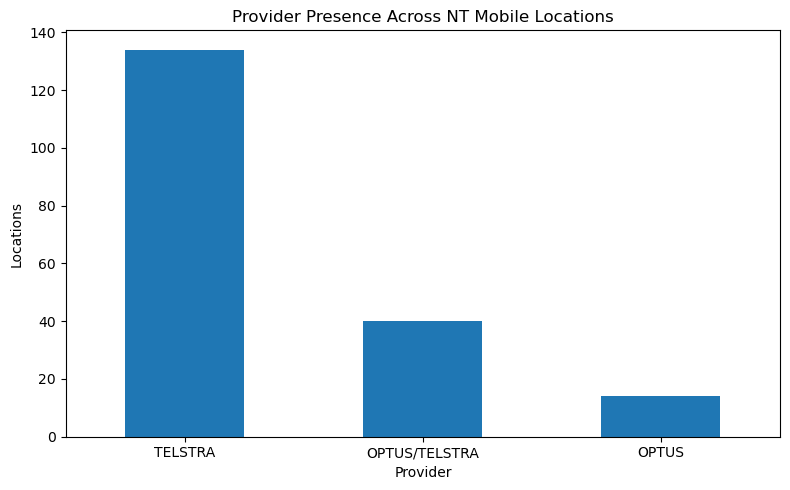

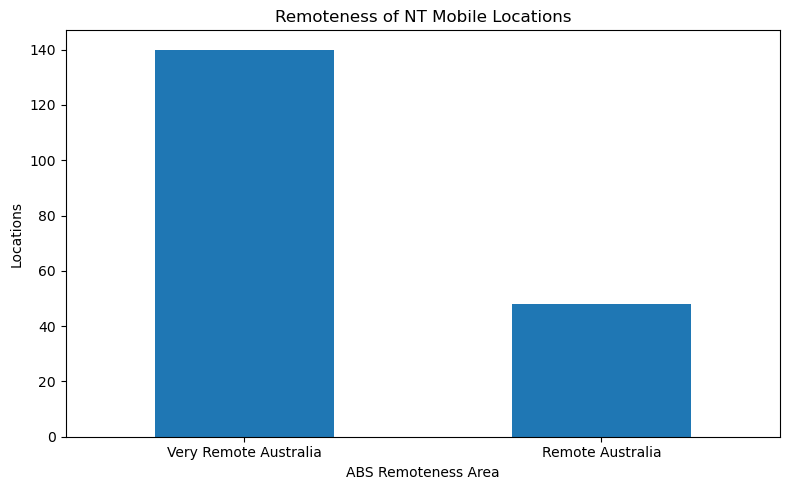

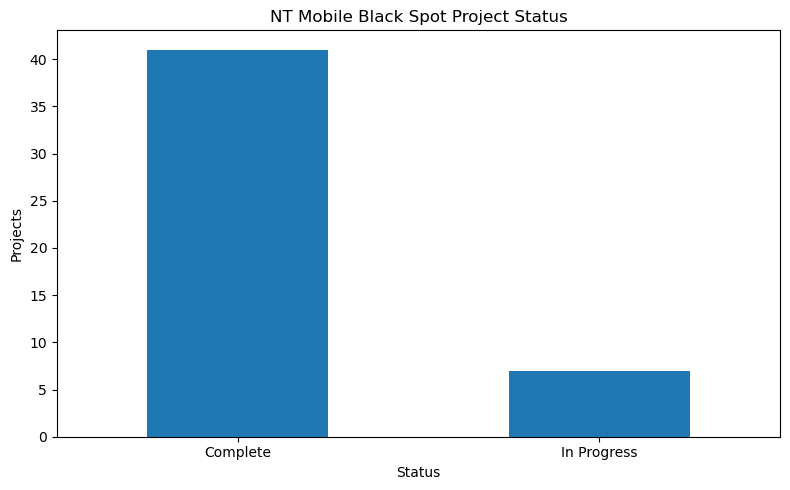

In [11]:
mobile["provider"].value_counts().plot(kind="bar", figsize=(8,5))
plt.title("Provider Presence Across NT Mobile Locations")
plt.xlabel("Provider")
plt.ylabel("Locations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

mobile["remoteness"].value_counts().plot(kind="bar", figsize=(8,5))
plt.title("Remoteness of NT Mobile Locations")
plt.xlabel("ABS Remoteness Area")
plt.ylabel("Locations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

blackspots["site_status"].value_counts().plot(kind="bar", figsize=(8,5))
plt.title("NT Mobile Black Spot Project Status")
plt.xlabel("Status")
plt.ylabel("Projects")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
mobile_output = CLEAN_DIR / "nt_mobile_coverage_enriched.csv"
blackspot_output = CLEAN_DIR / "nt_black_spots_clean.csv"

mobile.to_csv(mobile_output, index=False)
blackspots.to_csv(blackspot_output, index=False)

mobile.to_json(
    APP_DIR / "mobile_locations.json",
    orient="records",
    indent=2,
    force_ascii=False
)
blackspots.to_json(
    APP_DIR / "black_spots.json",
    orient="records",
    indent=2,
    force_ascii=False
)

print("Saved:", mobile_output)
print("Saved:", blackspot_output)
print("Saved app JSON files to:", APP_DIR)

Saved: C:\Users\HP\OneDrive\เอกสาร\remote-connectivity\data\cleaned\nt_mobile_coverage_enriched.csv
Saved: C:\Users\HP\OneDrive\เอกสาร\remote-connectivity\data\cleaned\nt_black_spots_clean.csv
Saved app JSON files to: C:\Users\HP\OneDrive\เอกสาร\remote-connectivity\data\app
